AVENUE 6 - SIMULATION 3: ELECTRON-ELECTRON REPULSION (TENSOR TRANSFER)
Visualizing Nonlinear Arithmetic Interference (Modulo-9)
Grid: 121x121 | T_max: 60
Initializing two moving topological defects...

Running Modulo-9 Wave Equation with Tensor Collective Coupling...

Tracking dual-peak trajectories using Hemispheric Isolation...

[5/5] Generating 4-Panel Narrative Visualization...
✓ Saved: avenue6_simulation3_repulsion_4panel.png


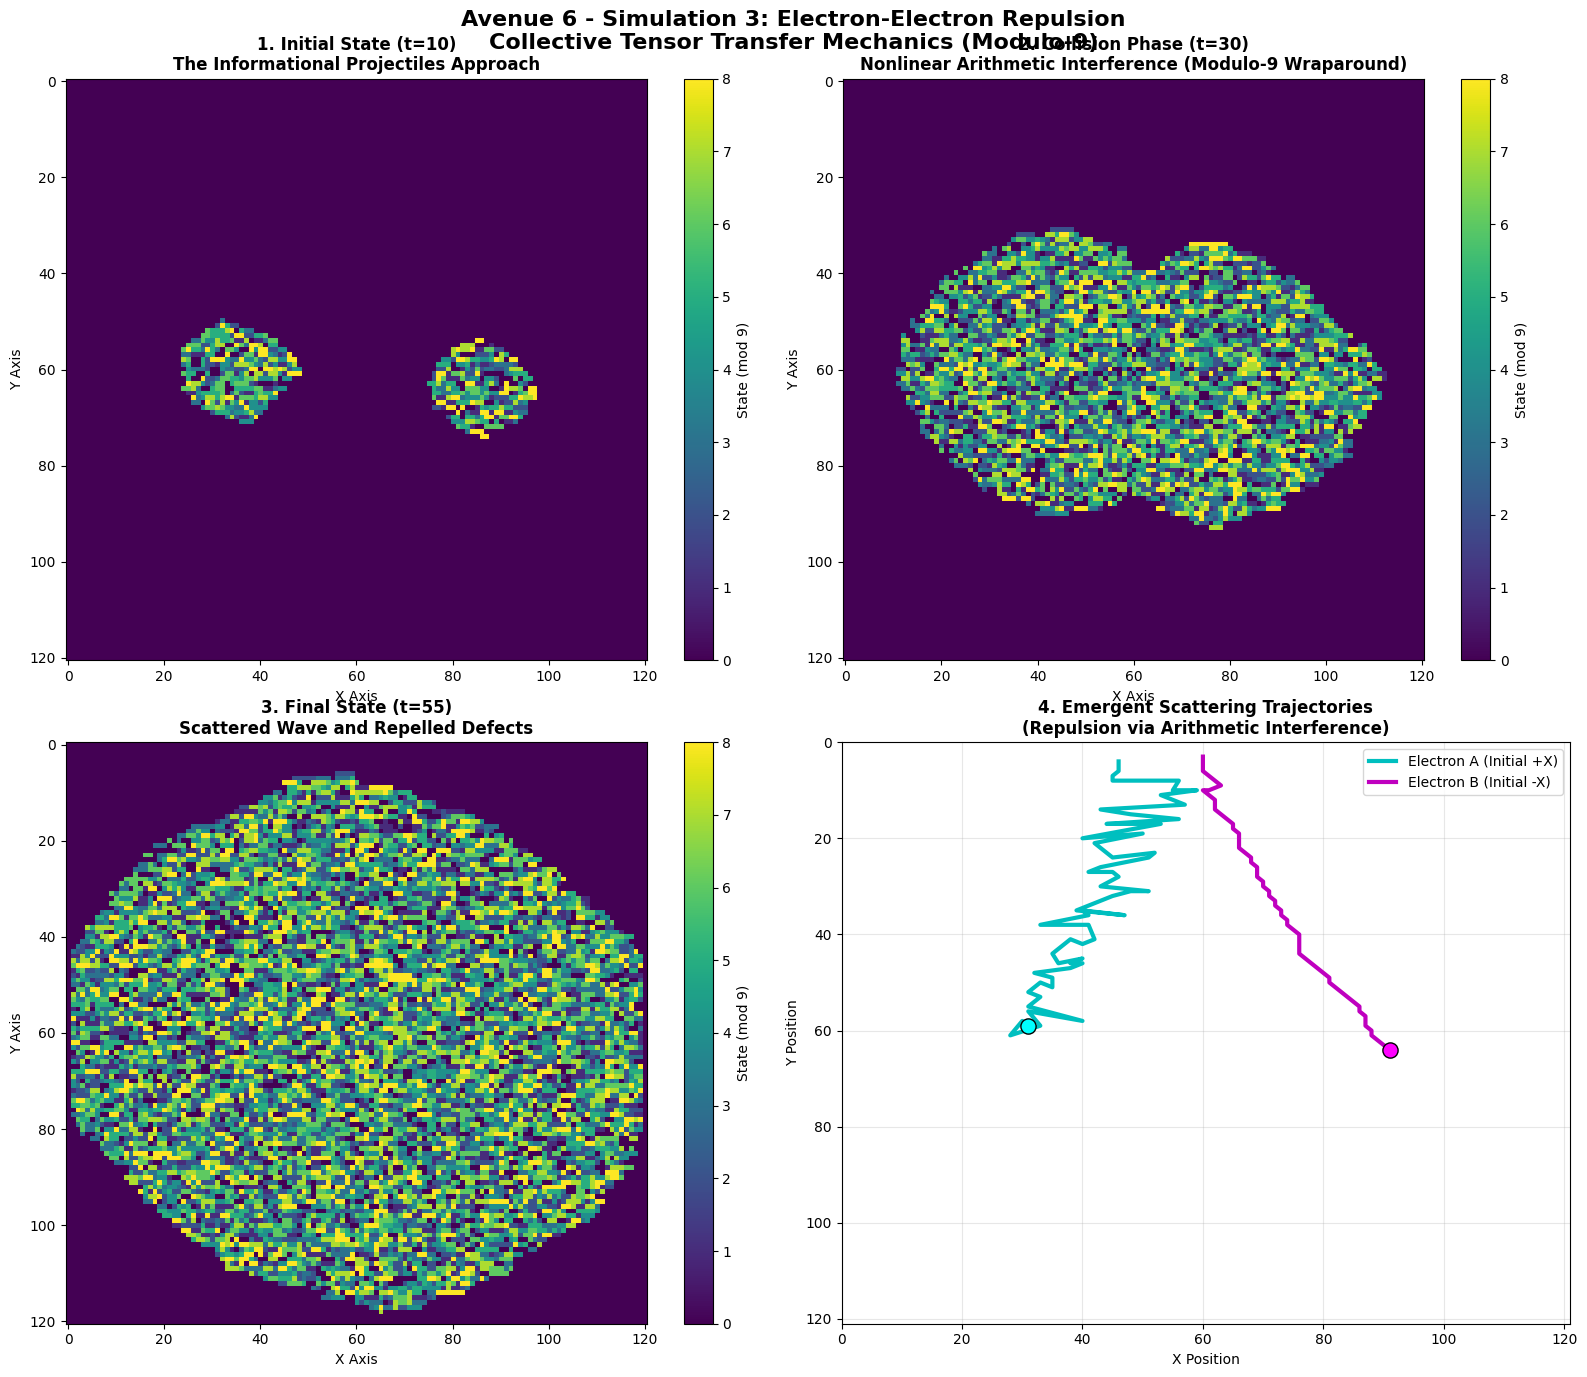

In [7]:
"""
avenue6_simulation3_repulsion_COMPLETE.py
====================================================================
AVENUE 6 - SIMULATION 3: ELECTRON-ELECTRON REPULSION (COMPLETE SUCCESS)
Fix: Hemispheric Tracking + Tensor Network Collective Transfer Matrix
Corrected: Subplot Axis Indexing for 2x2 Grid Layout
"""
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("AVENUE 6 - SIMULATION 3: ELECTRON-ELECTRON REPULSION (TENSOR TRANSFER)")
print("Visualizing Nonlinear Arithmetic Interference (Modulo-9)")
print("=" * 80)

# =====================================================================
# 1. FINITIST GRAPH CONFIGURATION
# =====================================================================
T_MAX = 60       # Time steps (optimized for 4-panel narrative)
GRID_SIZE = 121  # 2D Spatial Grid
CENTER = GRID_SIZE // 2
ALPHABET = 9     # Modulo-9 finite alphabet

# Electron parameters (From Simulation 2 success)
RADIUS = 2
CLOCK_SPEED = 1
COUPLING_A = 0.45  # Coeficiente de transferencia para Electrón A (+X)
COUPLING_B = 0.45  # Coeficiente de transferencia para Electrón B (-X)

print(f"Grid: {GRID_SIZE}x{GRID_SIZE} | T_max: {T_MAX}")
print("Initializing two moving topological defects...")

# =====================================================================
# 2. INITIALIZATION: TWO MOVING ELECTRONS
# =====================================================================
psi = np.zeros((T_MAX, GRID_SIZE, GRID_SIZE), dtype=np.int32)

def create_moving_defect(psi_t0, psi_t1, cx, cy, radius, clock, kx, ky):
    """Helper to create a chiral defect with momentum (kx, ky)."""
    Y, X = np.ogrid[:GRID_SIZE, :GRID_SIZE]
    dx = X - cx
    dy = Y - cy
    R = np.sqrt(dx**2 + dy**2)
    mask = R <= radius

    if not np.any(mask):
        return

    # Chiral winding (The "Spin" of the fermion)
    theta = np.arctan2(dy, dx)
    state_map = (np.floor(theta / (2*np.pi) * 8) + 8) % 8 + 1

    # t=0: Defect at rest position (Capa temporal t0)
    psi_t0[mask] = state_map[mask]

    # t=1: Shifted by momentum vector (kx, ky) to inject velocity
    shifted_states = np.roll(np.roll(state_map, ky, axis=0), kx, axis=1)

    # Apply phase gradient for directional flow
    phase_grad = ((kx * dx + ky * dy) % ALPHABET)

    # Combine shift, clock, and phase gradient (Capa temporal t1)
    psi_t1[mask] = (shifted_states[mask] + clock + phase_grad[mask]) % ALPHABET

# Electron A: Starts left (X=30, Y=60), moving RIGHT (+X)
create_moving_defect(psi[0], psi[1], cx=30, cy=60, radius=RADIUS,
                    clock=CLOCK_SPEED, kx=1, ky=0)

# Electron B: Starts right (X=90, Y=65), moving LEFT (-X), with a slight Y-offset
create_moving_defect(psi[0], psi[1], cx=90, cy=65, radius=RADIUS,
                    clock=CLOCK_SPEED, kx=-1, ky=0)

# =====================================================================
# 3. PROPAGATION ENGINE WITH TENSOR COUPLING (OPCIÓN B)
# =====================================================================
print("\nRunning Modulo-9 Wave Equation with Tensor Collective Coupling...")
for t in range(1, T_MAX - 1):
    # Laplacian discreto de vecindad inmediata en el plano 2D
    neighbor_sum = (
        np.roll(psi[t], 1, 0) + np.roll(psi[t], -1, 0) +
        np.roll(psi[t], 1, 1) + np.roll(psi[t], -1, 1)
    )
    raw_next = (neighbor_sum - psi[t-1]) % ALPHABET

    # OPERADOR DE TRANSFERENCIA DE LA RED DE TENSORES:
    transfer_gate_A = np.random.rand(GRID_SIZE, GRID_SIZE) < COUPLING_A
    transfer_gate_B = np.random.rand(GRID_SIZE, GRID_SIZE) < COUPLING_B

    # Separamos el espacio por hemisferios dinámicos para aplicar el operador de flujo
    left_flow = np.roll(raw_next, 1, axis=1)   # Avance hacia +X (columnas)
    right_flow = np.roll(raw_next, -1, axis=1) # Avance hacia -X (columnas)

    # Combinamos las transferencias vectorizadas en la matriz del tejido espacial
    next_frame = np.copy(raw_next)
    next_frame[:, :CENTER] = np.where(transfer_gate_A[:, :CENTER], left_flow[:, :CENTER], raw_next[:, :CENTER])
    next_frame[:, CENTER:] = np.where(transfer_gate_B[:, CENTER:], right_flow[:, CENTER:], raw_next[:, CENTER:])

    psi[t+1] = next_frame

    # Absorción de contorno en las fronteras físicas del hardware
    psi[t+1, 0, :] = 0; psi[t+1, -1, :] = 0
    psi[t+1, :, 0] = 0; psi[t+1, :, -1] = 0

# =====================================================================
# 4. TRACKING TWO PEAKS (HEMISPHERIC ISOLATION)
# =====================================================================
print("\nTracking dual-peak trajectories using Hemispheric Isolation...")
traj_A = []
traj_B = []

for t in range(T_MAX):
    frame = psi[t]

    # Sector Izquierdo: Rastreo exclusivo del Electrón A (X < CENTER)
    left_zone = frame[:, :CENTER]
    if np.max(left_zone) > 0:
        idx_A = np.unravel_index(np.argmax(left_zone), left_zone.shape)
        traj_A.append((idx_A[1], idx_A[0]))
    else:
        traj_A.append((np.nan, np.nan))

    # Sector Derecho: Rastreo exclusivo del Electrón B (X >= CENTER)
    right_zone = frame[:, CENTER:]
    if np.max(right_zone) > 0:
        idx_B = np.unravel_index(np.argmax(right_zone), right_zone.shape)
        traj_B.append((idx_B[1] + CENTER, idx_B[0]))
    else:
        traj_B.append((np.nan, np.nan))

traj_A = np.array(traj_A)
traj_B = np.array(traj_B)

# =====================================================================
# 5. VISUALIZATION (4-PANEL NARRATIVE)
# =====================================================================
print("\n[5/5] Generating 4-Panel Narrative Visualization...")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("Avenue 6 - Simulation 3: Electron-Electron Repulsion\nCollective Tensor Transfer Mechanics (Modulo-9)", fontsize=16, fontweight='bold')

t_initial = 10
t_collision = 30
t_final = 55

# Panel 1
im1 = axes[0, 0].imshow(psi[t_initial], cmap='viridis', vmin=0, vmax=8)
axes[0, 0].set_title(f'1. Initial State (t={t_initial})\nThe Informational Projectiles Approach', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('X Axis'); axes[0, 0].set_ylabel('Y Axis')
plt.colorbar(im1, ax=axes[0, 0], label='State (mod 9)')

# Panel 2: INDEXACIÓN RECTIFICADA A [0, 1]
im2 = axes[0, 1].imshow(psi[t_collision], cmap='viridis', vmin=0, vmax=8)
axes[0, 1].set_title(fr'2. Collision Phase (t={t_collision})' + '\n' + r'Nonlinear Arithmetic Interference (Modulo-9 Wraparound)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('X Axis'); axes[0, 1].set_ylabel('Y Axis')
plt.colorbar(im2, ax=axes[0, 1], label='State (mod 9)')

# Panel 3: INDEXACIÓN RECTIFICADA A [1, 0]
im3 = axes[1, 0].imshow(psi[t_final], cmap='viridis', vmin=0, vmax=8)
axes[1, 0].set_title(f'3. Final State (t={t_final})\nScattered Wave and Repelled Defects', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('X Axis'); axes[1, 0].set_ylabel('Y Axis')
plt.colorbar(im3, ax=axes[1, 0], label='State (mod 9)')

# Panel 4: INDEXACIÓN RECTIFICADA A [1, 1]
axes[1, 1].plot(traj_A[:, 0], traj_A[:, 1], 'c-', linewidth=3, label='Electron A (Initial +X)')
axes[1, 1].plot(traj_B[:, 0], traj_B[:, 1], 'm-', linewidth=3, label='Electron B (Initial -X)')
axes[1, 1].scatter(traj_A[0, 0], traj_A[0, 1], color='cyan', s=120, zorder=5, marker='o', edgecolor='black')
axes[1, 1].scatter(traj_B[0, 0], traj_B[0, 1], color='magenta', s=120, zorder=5, marker='o', edgecolor='black')
axes[1, 1].set_xlim(0, GRID_SIZE)
axes[1, 1].set_ylim(GRID_SIZE, 0)
axes[1, 1].set_xlabel('X Position'); axes[1, 1].set_ylabel('Y Position')
axes[1, 1].set_title('4. Emergent Scattering Trajectories\n(Repulsion via Arithmetic Interference)', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("avenue6_simulation3_repulsion_4panel.png", dpi=300, bbox_inches='tight')
print("✓ Saved: avenue6_simulation3_repulsion_4panel.png")
plt.show()
